# Autoencoder variacional

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

## Datos de entrenamiento

In [2]:
def get_batch(batch_size=1000, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

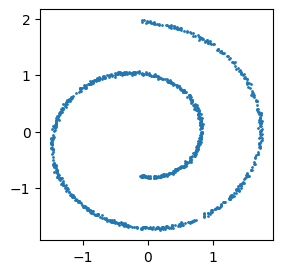

In [3]:
samples = get_batch()
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Redes neuronales

### Encoder

In [4]:
class Encoder(nn.Module):

    def __init__(self, data_dim, latent_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(data_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.mean = nn.Linear(32, latent_dim)
        self.log_std = nn.Linear(32, latent_dim)

    def forward(self, x):
        x = self.mlp(x)
        mean = self.mean(x)
        logstd = self.log_std(x)
        return mean, logstd.exp()

In [5]:
# Ejemplo de uso:

batch_size, data_dim, latent_dim = 1000, 2, 16

encoder = Encoder(data_dim, latent_dim)
x = torch.randn(batch_size, data_dim)
mean, std = encoder(x)  # q(z|x).

assert mean.shape == (batch_size, latent_dim)
assert std.shape == (batch_size, latent_dim)

### Decoder

In [6]:
class Decoder(nn.Module):

    def __init__(self, data_dim, latent_dim):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, data_dim)
        )

    def forward(self, z):
        mean = self.decoder(z)
        return mean

In [7]:
# Ejemplo de uso:

batch_size, data_dim, latent_dim = 1000, 2, 16

decoder = Decoder(data_dim, latent_dim)
z = torch.randn(batch_size, latent_dim)
mean = decoder(z)

assert mean.shape == (batch_size, data_dim)

## Clase `VAE`

In [8]:
class VAE:

    def __init__(self, data_dim, latent_dim):

        self.latent_dim = latent_dim

        self.encoder = Encoder(data_dim, latent_dim)
        self.decoder = Decoder(data_dim, latent_dim)
        self.encoder_optimizer = optim.AdamW(self.encoder.parameters())
        self.decoder_optimizer = optim.AdamW(self.decoder.parameters())

        self.decoder_std = 0.1

    def train(self, iters):

        for _ in range(iters):

            x = get_batch()

            # Prior matching:
            encoder_mean, encoder_std = self.encoder(x)
            prior_matching = 1/2 * (encoder_mean.norm(dim=-1) ** 2 + encoder_std.norm(dim=-1) ** 2) - encoder_std.log().sum(dim=-1)

            # Reconstruction term:
            z = encoder_mean + encoder_std * torch.randn_like(encoder_mean)
            decoder_mean = self.decoder(z)
            reconstruction_term = - 1 / (2 * self.decoder_std ** 2) * (x - decoder_mean).norm(dim=-1) ** 2

            # ELBO:
            elbo = reconstruction_term - prior_matching
            loss = - elbo.mean()

            # Optimización:
            self.encoder_optimizer.zero_grad()
            self.decoder_optimizer.zero_grad()
            loss.backward()
            self.encoder_optimizer.step()
            self.decoder_optimizer.step()

    def reconstruct(self, x):
        z_mean, z_std = self.encoder(x)
        z = z_mean# + z_std * torch.randn_like(z_mean)
        x_mean = self.decoder(z)
        x_dec = x_mean# + self.decoder_std * torch.randn_like(x_mean)
        return x_dec

    def generate_samples(self, n_samples):
        z = torch.randn(n_samples, self.latent_dim)
        x_mean = self.decoder(z)
        x_dec = x_mean# + self.decoder_std * torch.randn_like(x_mean)
        return x_dec

    def latent_interpolation(self, x0, x1, t):

        # Latentes:
        z_0, _ = self.encoder(x0.unsqueeze(0))
        z_1, _ = self.encoder(x1.unsqueeze(0))

        # Interpolación:
        z_t = (1 - t) * z_0 + t * z_1
        x_t = self.decoder(z_t).squeeze(0)

        return x_t

## Entrenamiento

In [9]:
vae = VAE(data_dim=2, latent_dim=16)
vae.train(iters=50000)

KeyboardInterrupt: 

## Reconstrucción

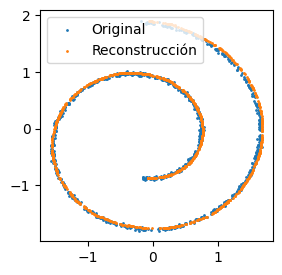

In [10]:
x = get_batch()
reconstruction = vae.reconstruct(x).detach()

plt.figure(figsize=(3, 3))
plt.scatter(x[:, 0], x[:, 1], s=1, label='Original')
plt.scatter(reconstruction[:, 0], reconstruction[:, 1], s=1, label='Reconstrucción')
plt.legend()
plt.show()

## Generación

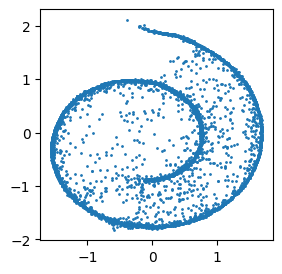

In [11]:
samples = vae.generate_samples(5000).detach()

plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Interpolación

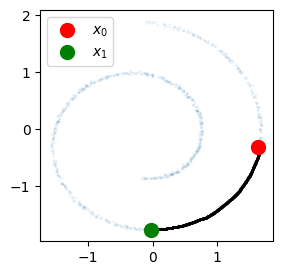

In [17]:
batch_x = get_batch()
x_0, x_1 = batch_x[0], batch_x[1]

plt.figure(figsize=(3, 3))
plt.scatter(batch_x[:, 0], batch_x[:, 1], s=1, alpha=0.05)

n_steps = 500
for t in torch.linspace(0, 1, n_steps):
    x_t = vae.latent_interpolation(x_0, x_1, t).detach()
    plt.scatter(*x_t, s=1, color='k')

plt.scatter(*x_0, s=100, color='r', label='$x_0$')
plt.scatter(*x_1, s=100, color='g', label='$x_1$')

plt.legend()
plt.show()